# 1. Import Libraries

In [27]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Loading Data

In [2]:
df = pd.read_csv("Fraud_raw.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


# 2. Data Cleaning

In [7]:
df.isna().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

In [9]:
df['Fraudulent'].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

# 3. Feature Engineering

In [11]:
df['Transaction_Date'] = pd.to_datetime(
    df['Transaction_Date'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [13]:
df['Month'] = df['Transaction_Date'].dt.month
df['Weekday'] = df['Transaction_Date'].dt.weekday
df['Is_Weekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [15]:
df['Spend_Deviation'] = (
    df['Transaction_Amount'] - df['Average_Spend']
)

In [17]:
df['Spend_Ratio'] = (
    df['Transaction_Amount'] / (df['Average_Spend'] + 1)
)

In [19]:
df['High_Value_Transaction'] = (
    df['Transaction_Amount'] > 500
).astype(int)

In [21]:
df['Customer_Activity_Score'] = (
    df['Previous_Transactions'] * df['Account_Age_Days']
)

In [23]:
df['Transactions_Per_Day'] = (
    df['Previous_Transactions'] /
    (df['Account_Age_Days'] + 1)
)

In [25]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent',
       'Month', 'Weekday', 'Is_Weekend', 'Spend_Deviation', 'Spend_Ratio',
       'High_Value_Transaction', 'Customer_Activity_Score',
       'Transactions_Per_Day'],
      dtype='object')

# 4. Exploratory Data Analysis (EDA)

# Fraud vs Genuine Transactions

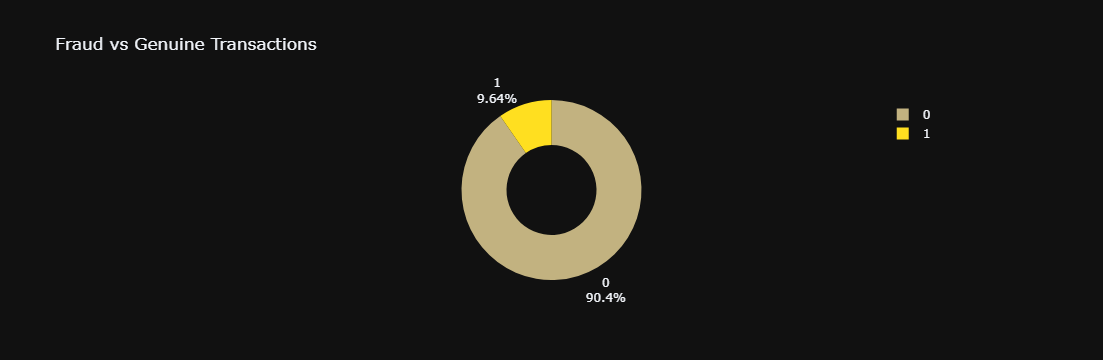

In [67]:
fraud_count = df['Fraudulent'].value_counts().reset_index()

fig = px.pie(
    fraud_count,
    names='Fraudulent',
    values='count',
    title='Fraud vs Genuine Transactions',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    hole=0.5
)

fig.update_traces(textinfo='percent+label', textposition='outside', marker_line=dict(color='#000047'))
fig.update_layout(template='plotly_dark')

fig.show()

# Transaction Amount Distribution

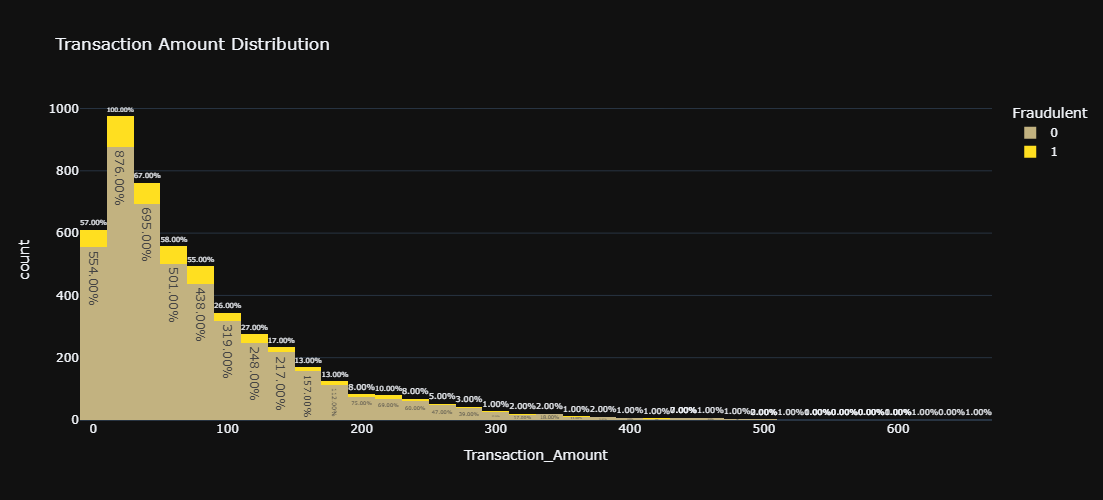

In [159]:
fig = px.histogram(
    df,
    x='Transaction_Amount',
    color='Fraudulent',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    nbins=50,
    title='Transaction Amount Distribution'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(template='plotly_dark', height=500)
fig.show()

# Fraud by Payment Method

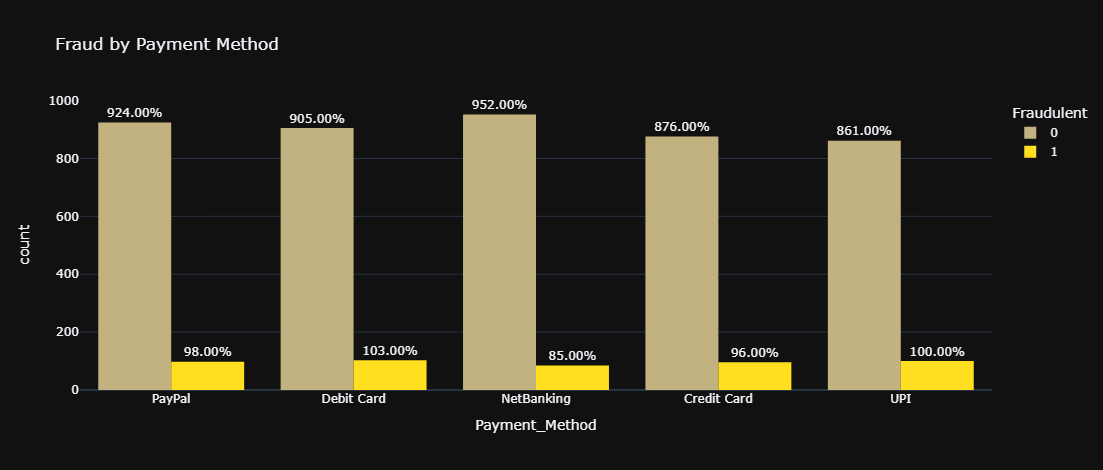

In [105]:
fig = px.histogram(
    df,
    x='Payment_Method',
    color='Fraudulent',
    barmode='group',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    title='Fraud by Payment Method'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(template='plotly_dark', height=470)
fig.show()

# Fraud by Merchant Category

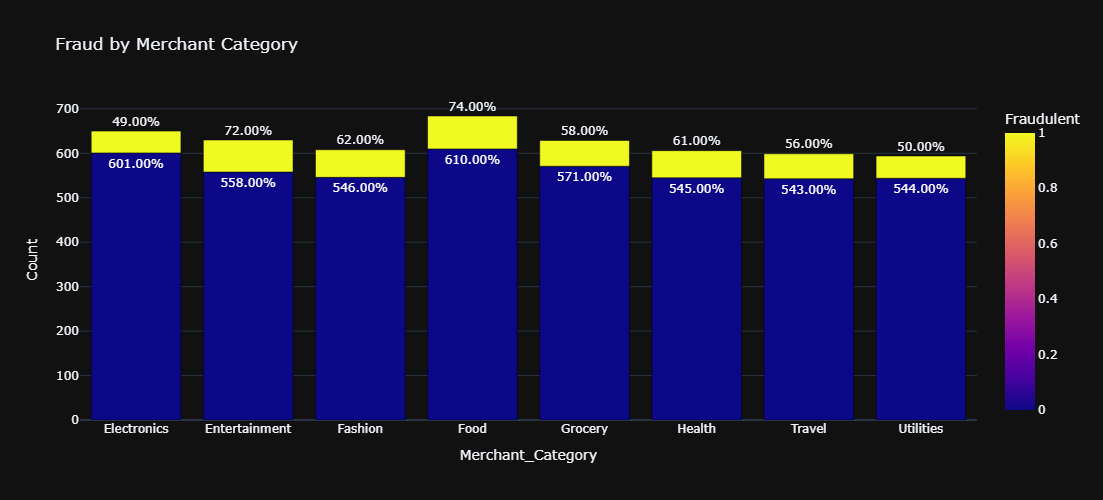

In [109]:
fig = px.bar(
    df.groupby(['Merchant_Category', 'Fraudulent'])
      .size()
      .reset_index(name='Count'),

    x='Merchant_Category',
    y='Count',
    color='Fraudulent',
    title='Fraud by Merchant Category'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(template='plotly_dark', height=500)
fig.show()

# Fraud by Device Type

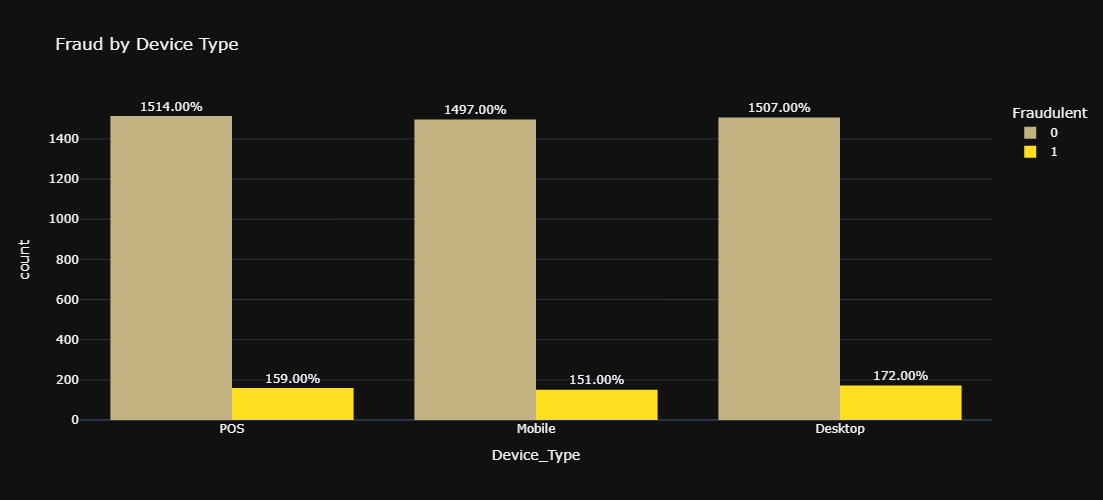

In [113]:
fig = px.histogram(
    df,
    x='Device_Type',
    color='Fraudulent',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    barmode='group',
    title='Fraud by Device Type'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(template='plotly_dark',height=500)
fig.show()

# International vs Domestic Fraud

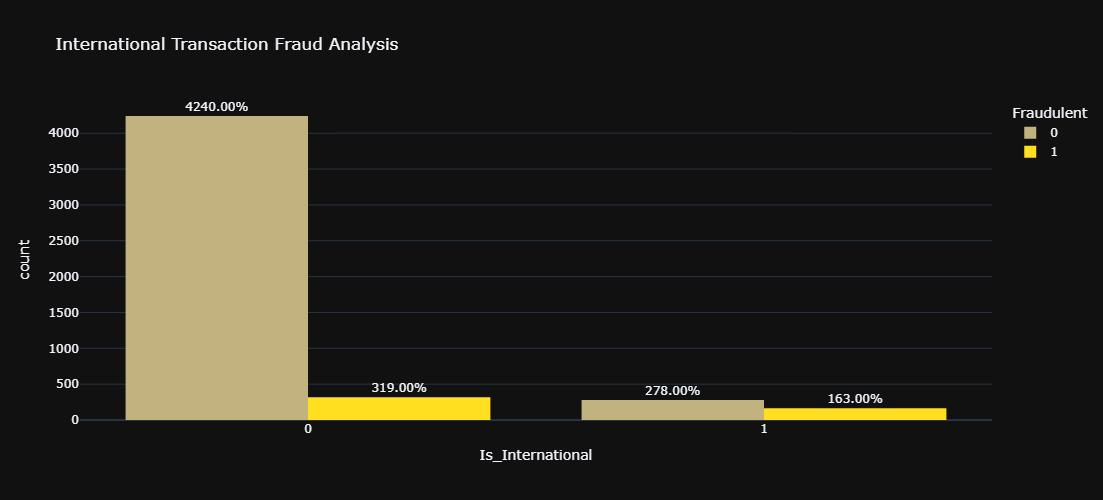

In [119]:
fig = px.histogram(
    df,
    x='Is_International',
    color='Fraudulent',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    barmode='group',
    title='International Transaction Fraud Analysis'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%', textposition='outside')
fig.update_layout(template='plotly_dark',height=500)
fig.show()

# Weekend Fraud Analysis

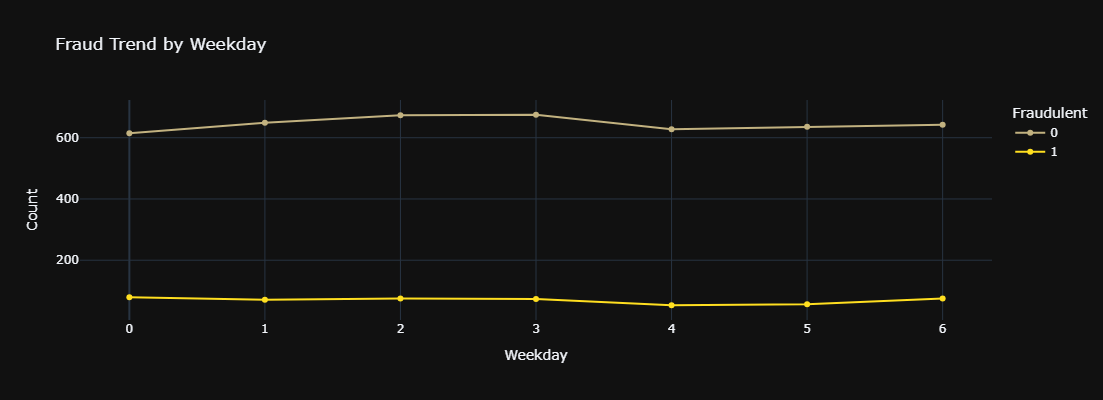

In [131]:
fig = px.line(
    df.groupby(['Weekday', 'Fraudulent'])
      .size()
      .reset_index(name='Count'),

    x='Weekday',
    y='Count',
    color='Fraudulent',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    markers=True,

    title='Fraud Trend by Weekday'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%')
fig.update_layout(template='plotly_dark',height=400)
fig.show()

# Customer Activity Score vs Fraud

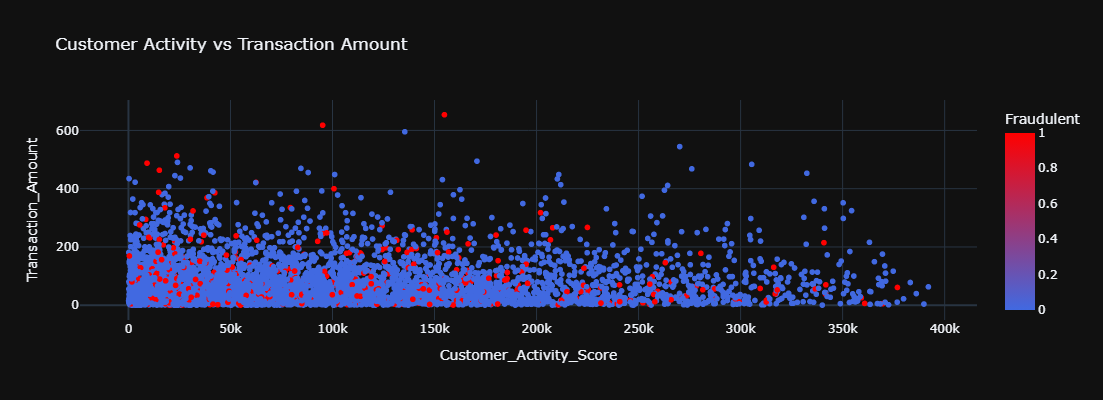

In [203]:
fig = px.scatter(
    df,
    x='Customer_Activity_Score',
    y='Transaction_Amount',
    color='Fraudulent',
    color_continuous_scale=['royalblue', 'red'],
    title='Customer Activity vs Transaction Amount'
)

fig.update_layout(template='plotly_dark',height=400)
fig.show()

# Monthly Fraud Trend

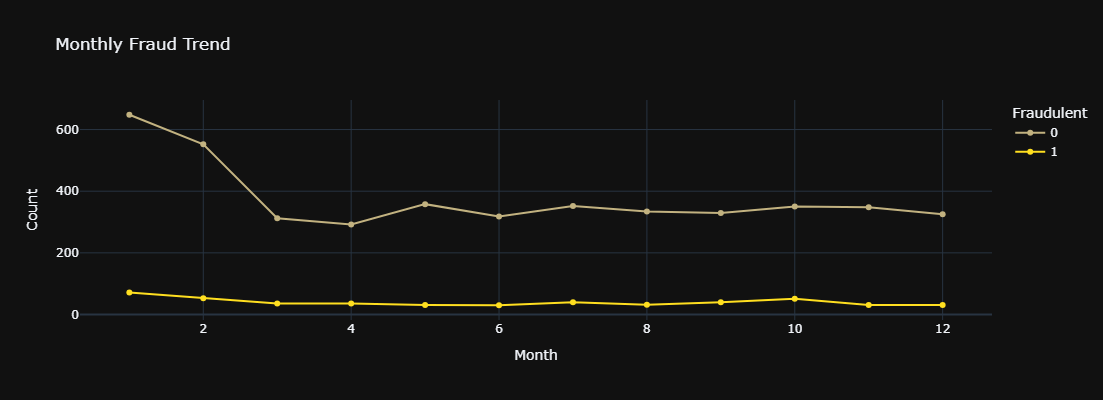

In [147]:
fig = px.line(
    df.groupby(['Month', 'Fraudulent'])
      .size()
      .reset_index(name='Count'),

    x='Month',
    y='Count',
    color='Fraudulent',
    color_discrete_sequence=['#C2B280', '#FFDF20'],
    markers=True,

    title='Monthly Fraud Trend'
)

fig.update_traces(marker_line=dict(color='black'),texttemplate='%{y:.2f}%')
fig.update_layout(template='plotly_dark',height=400)
fig.show()

# 5. Encoding Categorical Features

In [236]:
from sklearn.preprocessing import LabelEncoder

# Store mappings
label_mappings = {}

cat_cols = [
    'Merchant_Category',
    'Payment_Method',
    'Device_Type',
    'Location',
    'Suspicious_Keyword'
]

# Encoding + Saving Mapping
for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    # Save mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))

    label_mappings[col] = mapping


# ==========================================
# PRINT ALL MAPPINGS
# ==========================================
for col, mapping in label_mappings.items():

    print(f"\n===== {col} =====")

    for category, label in mapping.items():
        print(f"{category} --> {label}")


===== Merchant_Category =====
Electronics --> 0
Entertainment --> 1
Fashion --> 2
Food --> 3
Grocery --> 4
Health --> 5
Travel --> 6
Utilities --> 7

===== Payment_Method =====
Credit Card --> 0
Debit Card --> 1
NetBanking --> 2
PayPal --> 3
UPI --> 4

===== Device_Type =====
Desktop --> 0
Mobile --> 1
POS --> 2

===== Location =====
Bengaluru --> 0
Chennai --> 1
Delhi --> 2
Hyderabad --> 3
Kolkata --> 4
Mumbai --> 5
Pune --> 6

===== Suspicious_Keyword =====
No --> 0
Yes --> 1


# 6. Data Preprocessing

In [238]:
import pandas as pd
import numpy as np
import pickle

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [240]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier

In [242]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Drop Columns

In [244]:
df.drop(
    columns=[
        "Transaction_ID",
        "Customer_ID",
        "Transaction_Date"
    ],
    inplace=True
)

# Define Features and Target

In [246]:
X = df.drop("Fraudulent", axis=1)
y = df["Fraudulent"]

In [248]:
df.head()

,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent,Month,Weekday,Is_Weekend,Spend_Deviation,Spend_Ratio,High_Value_Transaction,Customer_Activity_Score,Transactions_Per_Day
0,37.54,6,3,2,0,0,94,417.40,1492,0,0,10,2,0,-379.86,0.089723,0,140248,0.062960
1,240.81,7,3,1,0,0,76,335.47,66,0,0,9,1,0,-94.66,0.715695,0,5016,1.134328
2,105.34,1,1,1,0,0,60,432.03,216,0,0,7,1,0,-326.69,0.243263,0,12960,0.276498
3,73.04,7,2,0,4,0,68,488.30,449,0,0,10,0,0,-415.26,0.149274,0,30532,0.151111
4,13.57,7,0,0,0,0,57,437.03,754,0,0,9,5,1,-423.46,0.030980,0,42978,0.075497


# Train-Test Split

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# 7. Model Building

In [252]:
models = {
    
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=5,   # useful for imbalanced data
        random_state=42,
        eval_metric='logloss'
    )
}

# 8. Training Results

In [254]:
results = []

best_model = None
best_score = 0
best_model_name = ""

print("\n================ MODEL TRAINING ================\n")

for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Save Results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    
    # Print Metrics
    print(f"Accuracy  : {accuracy:.2f}")
    print(f"Precision : {precision:.2f}")
    print(f"Recall    : {recall:.2f}")
    print(f"F1 Score  : {f1:.2f}")
    print(f"ROC-AUC   : {roc_auc:.2f}")
    
    # Save Best Model
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = name


================ MODEL TRAINING ================


Training Logistic Regression...
Accuracy  : 0.76
Precision : 0.24
Recall    : 0.69
F1 Score  : 0.35
ROC-AUC   : 0.76

Training Decision Tree...
Accuracy  : 0.82
Precision : 0.27
Recall    : 0.52
F1 Score  : 0.35
ROC-AUC   : 0.68

Training Random Forest...
Accuracy  : 0.90
Precision : 0.46
Recall    : 0.36
F1 Score  : 0.41
ROC-AUC   : 0.76

Training Gradient Boosting...
Accuracy  : 0.91
Precision : 0.55
Recall    : 0.23
F1 Score  : 0.32
ROC-AUC   : 0.76

Training XGBoost...
Accuracy  : 0.90
Precision : 0.48
Recall    : 0.30
F1 Score  : 0.37
ROC-AUC   : 0.74


In [255]:
results_df = pd.DataFrame(results)

print("\n================ MODEL COMPARISON ================\n")
print(results_df.sort_values(by="ROC-AUC", ascending=False).round(2))


================ MODEL COMPARISON ================

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
2        Random Forest      0.90       0.46    0.36      0.41     0.76
0  Logistic Regression      0.76       0.24    0.69      0.35     0.76
3    Gradient Boosting      0.91       0.55    0.23      0.32     0.76
4              XGBoost      0.90       0.48    0.30      0.37     0.74
1        Decision Tree      0.82       0.27    0.52      0.35     0.68


# Best Model

In [256]:
print("\nBest Model :", best_model_name)
print(f"Best ROC-AUC Score : {best_score:.2f}")


Best Model : Random Forest
Best ROC-AUC Score : 0.76


# 9. Model Training

In [293]:
final_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )

In [295]:
final_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

# See Feature Names

In [297]:
feature_names = X.columns.tolist()

print("Total Features:", len(feature_names))

for i, feature in enumerate(feature_names):
    print(i, feature)

Total Features: 18
0 Transaction_Amount
1 Merchant_Category
2 Payment_Method
3 Device_Type
4 Location
5 Is_International
6 Previous_Transactions
7 Average_Spend
8 Account_Age_Days
9 Suspicious_Keyword
10 Month
11 Weekday
12 Is_Weekend
13 Spend_Deviation
14 Spend_Ratio
15 High_Value_Transaction
16 Customer_Activity_Score
17 Transactions_Per_Day


# 10. Feature Importance

In [319]:
importance = final_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
5          Is_International    0.189314
9        Suspicious_Keyword    0.139306
7             Average_Spend    0.069602
0        Transaction_Amount    0.066107
13          Spend_Deviation    0.065138
16  Customer_Activity_Score    0.064122
17     Transactions_Per_Day    0.063954
8          Account_Age_Days    0.062819
6     Previous_Transactions    0.060484
14              Spend_Ratio    0.060479
10                    Month    0.036861
1         Merchant_Category    0.029216
11                  Weekday    0.026741
4                  Location    0.023600
2            Payment_Method    0.022095
3               Device_Type    0.013506
12               Is_Weekend    0.005028
15   High_Value_Transaction    0.001629


# 11. Model Saving

In [299]:
with open('fraud_detection_model1.pkl', 'wb') as file:
    pickle.dump(final_model, file)

In [301]:
import pickle

pickle.dump(label_mappings, open("label_mappings.pkl", "wb"))

In [303]:
print(label_mappings['Payment_Method'])

{'Credit Card': 0, 'Debit Card': 1, 'NetBanking': 2, 'PayPal': 3, 'UPI': 4}


In [305]:
import pickle

# Load mapping
label_mappings = pickle.load(open("label_mappings.pkl", "rb"))

# Show mapping
print(label_mappings['Payment_Method'])

# Encode category
print(label_mappings['Payment_Method']['UPI'])

# Decode label
reverse_mapping = {
    v: k
    for k, v in label_mappings['Payment_Method'].items()
}

print(reverse_mapping[1])

{'Credit Card': 0, 'Debit Card': 1, 'NetBanking': 2, 'PayPal': 3, 'UPI': 4}
4
Debit Card


In [307]:
feature_names = X.columns.tolist()

with open('feature_names1.pkl', 'wb') as file:
    pickle.dump(feature_names, file)

In [309]:
with open('feature_names1.pkl', 'rb') as file:
    feature_names = pickle.load(file)

feature_names

['Transaction_Amount',
 'Merchant_Category',
 'Payment_Method',
 'Device_Type',
 'Location',
 'Is_International',
 'Previous_Transactions',
 'Average_Spend',
 'Account_Age_Days',
 'Suspicious_Keyword',
 'Month',
 'Weekday',
 'Is_Weekend',
 'Spend_Deviation',
 'Spend_Ratio',
 'High_Value_Transaction',
 'Customer_Activity_Score',
 'Transactions_Per_Day']

In [311]:
print(X_train.shape[1])
print(X.columns.tolist())

18
['Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Month', 'Weekday', 'Is_Weekend', 'Spend_Deviation', 'Spend_Ratio', 'High_Value_Transaction', 'Customer_Activity_Score', 'Transactions_Per_Day']


In [313]:
df

,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent,Month,Weekday,Is_Weekend,Spend_Deviation,Spend_Ratio,High_Value_Transaction,Customer_Activity_Score,Transactions_Per_Day
0,37.54,6,3,2,0,0,94,417.40,1492,0,0,10,2,0,-379.86,0.089723,0,140248,0.062960
1,240.81,7,3,1,0,0,76,335.47,66,0,0,9,1,0,-94.66,0.715695,0,5016,1.134328
2,105.34,1,1,1,0,0,60,432.03,216,0,0,7,1,0,-326.69,0.243263,0,12960,0.276498
3,73.04,7,2,0,4,0,68,488.30,449,0,0,10,0,0,-415.26,0.149274,0,30532,0.151111
4,13.57,7,0,0,0,0,57,437.03,754,0,0,9,5,1,-423.46,0.030980,0,42978,0.075497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,182.15,0,1,1,4,0,13,277.99,840,0,0,8,1,0,-95.84,0.652891,0,10920,0.015458
4996,10.17,2,0,0,1,0,128,477.24,441,0,0,1,6,1,-467.07,0.021265,0,56448,0.289593
4997,31.78,4,1,1,4,1,76,442.62,1474,0,1,1,0,0,-410.84,0.071638,0,112024,0.051525
4998,135.31,7,1,1,0,0,13,73.33,246,0,0,8,4,0,61.98,1.820396,0,3198,0.052632


# 12. Manual Script for checking Model Performance 

In [315]:
import pickle
import pandas as pd
import numpy as np

# =========================
# LOAD MODEL
# =========================

with open('fraud_detection_model1.pkl', 'rb') as file:
    model = pickle.load(file)

# =========================
# LOAD LABEL MAPPINGS
# =========================

with open('label_mappings.pkl', 'rb') as file:
    label_mappings = pickle.load(file)

# =========================
# LOAD FEATURE NAMES
# =========================

with open('feature_names1.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# =========================
# SHOW ENCODING MAPPINGS
# =========================

categorical_cols = [
    'Merchant_Category',
    'Payment_Method',
    'Device_Type',
    'Location',
    'Suspicious_Keyword'
]

print("\n========== LABEL MAPPINGS ==========")

for col in categorical_cols:
    
    print(f"\n{col}")
    
    for category, label in label_mappings[col].items():
        print(f"{category} --> {label}")

# =========================
# MANUAL INPUT DATA
# =========================

input_data = {

    'Transaction_Amount': 25000,

    # Encoded values
    'Merchant_Category': 0,

    'Payment_Method': 0,

    'Device_Type': 1,

    'Location': 2,

    'Is_International': 1,

    'Previous_Transactions': 2,

    'Average_Spend': 5000,

    'Account_Age_Days': 20,

    'Suspicious_Keyword': 1,

    'Month': 8,

    'Weekday': 4,

    'Is_Weekend': 1,

    'Spend_Deviation': -94.66,

    'Spend_Ratio': 0.7156,

    'High_Value_Transaction': 0,

    'Customer_Activity_Score': 5016,

    'Transactions_Per_Day': 1.1343
}

# =========================
# CONVERT TO DATAFRAME
# =========================

input_df = pd.DataFrame([input_data])

# Ensure same feature order
input_df = input_df[feature_names]

# =========================
# PREDICTION
# =========================

prediction = model.predict(input_df)[0]

# Fraud probability
probability = model.predict_proba(input_df)[0][1]

# =========================
# OUTPUT
# =========================

print("\n========== FRAUD DETECTION RESULT ==========")

if prediction == 1:
    print("⚠ Fraudulent Transaction Detected")

else:
    print("✓ Genuine Transaction")

print(f"\nFraud Probability: {probability:.2f}")

# =========================
# RISK LEVEL
# =========================

if probability >= 0.8:
    print("Risk Level: HIGH")

elif probability >= 0.5:
    print("Risk Level: MEDIUM")

else:
    print("Risk Level: LOW")


========== LABEL MAPPINGS ==========

Merchant_Category
Electronics --> 0
Entertainment --> 1
Fashion --> 2
Food --> 3
Grocery --> 4
Health --> 5
Travel --> 6
Utilities --> 7

Payment_Method
Credit Card --> 0
Debit Card --> 1
NetBanking --> 2
PayPal --> 3
UPI --> 4

Device_Type
Desktop --> 0
Mobile --> 1
POS --> 2

Location
Bengaluru --> 0
Chennai --> 1
Delhi --> 2
Hyderabad --> 3
Kolkata --> 4
Mumbai --> 5
Pune --> 6

Suspicious_Keyword
No --> 0
Yes --> 1

========== FRAUD DETECTION RESULT ==========
✓ Genuine Transaction

Fraud Probability: 0.27
Risk Level: LOW
